In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from copy import deepcopy
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import mutual_info_regression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [2]:
sns.set_style("whitegrid")
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
df = pd.read_csv("/kaggle/input/sleep-health-and-lifestyle-dataset/Sleep_health_and_lifestyle_dataset.csv")
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df.head()

,person_id,gender,age,occupation,sleep_duration,quality_of_sleep,physical_activity_level,stress_level,bmi_category,blood_pressure,heart_rate,daily_steps,sleep_disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [4]:
placeholders = ['?', 'na', 'n/a', '-', '--', 'none', 'null', 'nan', '']
dfc = df.copy()
for c in dfc.columns:
    if dfc[c].dtype == object:
        s = dfc[c].astype(str).str.strip()
        dfc[c] = s.replace({p: np.nan for p in placeholders})

for c in dfc.columns:
    x = pd.to_numeric(dfc[c], errors='coerce')
    if x.notna().mean() >= 0.6:
        dfc[c] = x

df = dfc.copy()
df.head()

,person_id,gender,age,occupation,sleep_duration,quality_of_sleep,physical_activity_level,stress_level,bmi_category,blood_pressure,heart_rate,daily_steps,sleep_disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [5]:
target = "sleep_duration"
df[target] = pd.to_numeric(df[target], errors='coerce')
df.fillna(df.median(numeric_only=True), inplace=True)
skew = df[target].skew()

if abs(skew) > 1:
    y_all = np.log1p(df[target].values)
    inv = lambda x: np.expm1(x)
    use_log = True
else:
    y_all = df[target].values
    inv = lambda x: x
    use_log = False


In [6]:
X_df = df.drop(columns=[target]).copy()
label_encoders = {}
for col in X_df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    X_df[col] = le.fit_transform(X_df[col].astype(str))
    label_encoders[col] = le

X_df = X_df.select_dtypes(include=[np.number])
X_df.head()

,person_id,gender,age,occupation,quality_of_sleep,physical_activity_level,stress_level,bmi_category,blood_pressure,heart_rate,daily_steps,sleep_disorder
0,1,1,27,9,6,42,6,3,11,77,4200,2
1,2,1,28,1,6,60,8,0,9,75,10000,2
2,3,1,28,1,6,60,8,0,9,75,10000,2
3,4,1,28,6,4,30,8,2,22,85,3000,1
4,5,1,28,6,4,30,8,2,22,85,3000,1


In [7]:
X = X_df.copy()

if 'daily_steps' in X.columns and 'age' in X.columns:
    X['steps_per_age'] = X['daily_steps'] / X['age'].replace(0, np.nan)
    X['steps_per_age'] = X['steps_per_age'].fillna(0)

for c in list(X.columns):
    if (X[c] > 0).all() and X[c].skew() > 1:
        X[f"log1p_{c}"] = np.log1p(X[c])

X.shape

(374, 14)

In [8]:
mi = mutual_info_regression(X.fillna(0), y_all)
mi_s = pd.Series(mi, index=X.columns).sort_values(ascending=False)
top_features = mi_s.head(min(30, len(mi_s))).index.tolist()
X_sel = X[top_features].copy()
X_sel.shape

(374, 14)

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sel.fillna(0))
y_arr = np.array(y_all)
X_scaled.shape, y_arr.shape

((374, 14), (374,))

In [10]:
class TabularDataset(Dataset):
    def __init__(self, X, y, transform=None, target_transform=None):
        self.X = torch.as_tensor(X, dtype=torch.float32)
        self.y = torch.as_tensor(y, dtype=torch.float32).reshape(-1, 1)
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        x = self.X[idx]
        y = self.y[idx]

        if self.transform:
            x = self.transform(x)
        if self.target_transform:
            y = self.target_transform(y)

        return x, y

In [11]:
class MLP(nn.Module):
    def __init__(self, in_dim):
        super().__init__()

        self.layer1 = nn.Sequential(
            nn.Linear(in_dim, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(0.15)
        )

        self.layer2 = nn.Sequential(
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.Dropout(0.15)
        )

        self.layer3 = nn.Sequential(
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.GELU(),
            nn.Dropout(0.10)
        )

        self.out = nn.Linear(32, 1)

        # kaiming init → better performance
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        return self.out(x)


In [12]:
def train_cv_torch(X, y, folds=3, epochs=200, batch=16, lr=1e-3, wd=1e-5, patience=25):
    kf = KFold(n_splits=folds, shuffle=True, random_state=SEED)
    oof = np.zeros(len(y))
    models = []
    for f, (tr, va) in enumerate(kf.split(X)):
        Xtr, Xva = X[tr], X[va]
        ytr, yva = y[tr], y[va]
        tr_ds = TabularDataset(Xtr, ytr)
        va_ds = TabularDataset(Xva, yva)
        tr_dl = DataLoader(tr_ds, batch_size=min(batch, len(tr_ds)), shuffle=True)
        va_dl = DataLoader(va_ds, batch_size=len(va_ds), shuffle=False)
        model = MLP(X.shape[1]).to(DEVICE)
        opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
        sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=8)
        loss_fn = nn.SmoothL1Loss()
        best = 1e12
        wait = 0
        best_state = None
        for e in range(1, epochs+1):
            model.train()
            for xb, yb in tr_dl:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                opt.zero_grad()
                p = model(xb)
                loss = loss_fn(p, yb)
                loss.backward()
                opt.step()
            model.eval()
            val_losses = []
            with torch.no_grad():
                for xb, yb in va_dl:
                    xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                    p = model(xb)
                    val_losses.append(loss_fn(p, yb).item())
            vloss = np.mean(val_losses)
            sch.step(vloss)
            if vloss < best:
                best = vloss
                wait = 0
                best_state = deepcopy(model.state_dict())
            else:
                wait += 1
            if wait >= patience:
                break
        model.load_state_dict(best_state)
        models.append(deepcopy(model))
        model.eval()
        with torch.no_grad():
            Xva_t = torch.tensor(Xva, dtype=torch.float32).to(DEVICE)
            preds = model(Xva_t).cpu().numpy().squeeze()
        oof[va] = preds
    return oof, models

In [13]:
oof_preds_torch, torch_models = train_cv_torch(X_scaled, y_arr, folds=3, epochs=200, batch=16)
if use_log:
    y_true = inv(y_arr)
    preds_torch = inv(oof_preds_torch)
else:
    y_true = y_arr
    preds_torch = oof_preds_torch
mse_t = mean_squared_error(y_true, preds_torch)
rmse_t = np.sqrt(mse_t)
mae_t = mean_absolute_error(y_true, preds_torch)
r2_t = r2_score(y_true, preds_torch)
mape_t = np.mean(np.abs((y_true - preds_torch) / np.clip(np.abs(y_true), 1e-8, None))) * 100
accuracy_like_t = 100 - mape_t
mse_t, rmse_t, mae_t, r2_t, mape_t, accuracy_like_t


(0.10839596747343536,
 0.3292354286425374,
 0.26854033291658613,
 0.8283181382451186,
 3.7375729699927183,
 96.26242703000729)

In [14]:
import lightgbm as lgb   # <-- REQUIRED IMPORT

def lgb_cv_predict(X, y, n_splits=3, params=None, num_round=300, early_stopping_rounds=40):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    oof = np.zeros(len(y))
    models = []
    
    for fold, (tr_idx, val_idx) in enumerate(kf.split(X)):
        X_tr, X_va = X[tr_idx], X[val_idx]
        y_tr, y_va = y[tr_idx], y[val_idx]

        dtrain = lgb.Dataset(X_tr, label=y_tr)
        dval = lgb.Dataset(X_va, label=y_va)

        bst = lgb.train(
            params,
            dtrain,
            num_boost_round=num_round,
            valid_sets=[dval],
            callbacks=[lgb.early_stopping(stopping_rounds=early_stopping_rounds, verbose=False)]
        )

        oof[val_idx] = bst.predict(X_va, num_iteration=bst.best_iteration)
        models.append(bst)

    return oof, models

lgb_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.03,
    'num_leaves': 40,
    'min_data_in_leaf': 6,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbosity': -1
}

oof_preds_lgb, lgb_models = lgb_cv_predict(
    X_scaled, y_arr, n_splits=3, params=lgb_params,
    num_round=300, early_stopping_rounds=40
)

if use_log:
    preds_lgb = inv(oof_preds_lgb)
else:
    preds_lgb = oof_preds_lgb

mse_l = mean_squared_error(y_true, preds_lgb)
rmse_l = np.sqrt(mse_l)
mae_l = mean_absolute_error(y_true, preds_lgb)
r2_l = r2_score(y_true, preds_lgb)
mape_l = np.mean(np.abs((y_true - preds_lgb) / np.clip(np.abs(y_true), 1e-8, None))) * 100
accuracy_like_l = 100 - mape_l

mse_l, rmse_l, mae_l, r2_l, mape_l, accuracy_like_l


(0.009229490210440961,
 0.09607023581963854,
 0.061667293102644065,
 0.9853819648524722,
 0.88647681422895,
 99.11352318577104)

In [15]:
w_l, w_t = 0.6, 0.4
ensemble_preds = w_l * preds_lgb + w_t * preds_torch
mse_e = mean_squared_error(y_true, ensemble_preds)
rmse_e = np.sqrt(mse_e)
mae_e = mean_absolute_error(y_true, ensemble_preds)
r2_e = r2_score(y_true, ensemble_preds)
mape_e = np.mean(np.abs((y_true - ensemble_preds) / np.clip(np.abs(y_true), 1e-8, None))) * 100
accuracy_like_e = 100 - mape_e
mse_e, rmse_e, mae_e, r2_e, mape_e, accuracy_like_e

(0.026940968533473,
 0.16413704192982462,
 0.1230243649075343,
 0.9573298182292636,
 1.7214108504572296,
 98.27858914954277)

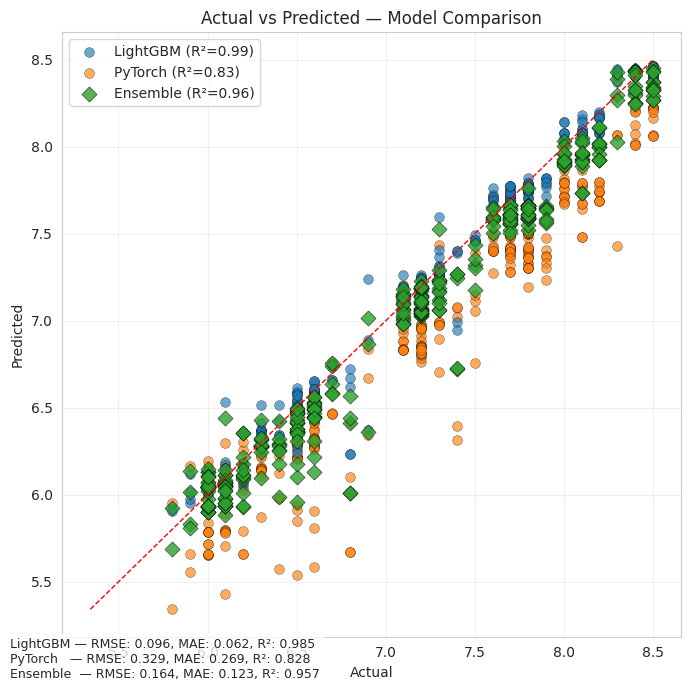

In [16]:
def safe_metrics(y, y_pred):
    y = np.array(y).ravel()
    y_pred = np.array(y_pred).ravel()
    mse = mean_squared_error(y, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    return dict(mse=mse, rmse=rmse, mae=mae, r2=r2)

required = {
    "LightGBM": ('preds_lgb' in globals()),
    "PyTorch": ('preds_torch' in globals()),
    "Ensemble": ('ensemble_preds' in globals())
}

if not any(required.values()):
    raise RuntimeError("No predictions found. Make sure preds_lgb, preds_torch, or ensemble_preds exist in the notebook.")

plt.figure(figsize=(7,7))
palette = sns.color_palette("tab10", n_colors=3)
plotted = 0

if required["LightGBM"]:
    m_l = safe_metrics(y_true, preds_lgb)
    plt.scatter(y_true, preds_lgb, alpha=0.65, label=f"LightGBM (R²={m_l['r2']:.2f})", s=50, edgecolor='k', linewidth=0.3, zorder=3)
    plotted += 1

if required["PyTorch"]:
    m_t = safe_metrics(y_true, preds_torch)
    plt.scatter(y_true, preds_torch, alpha=0.65, label=f"PyTorch (R²={m_t['r2']:.2f})", s=50, edgecolor='k', linewidth=0.3, zorder=2)
    plotted += 1

if required["Ensemble"]:
    m_e = safe_metrics(y_true, ensemble_preds)
    plt.scatter(y_true, ensemble_preds, alpha=0.8, label=f"Ensemble (R²={m_e['r2']:.2f})", s=60, marker='D', edgecolor='k', linewidth=0.4, zorder=4)
    plotted += 1

mn = float(min(np.min(y_true), 
               np.min(preds_lgb) if required["LightGBM"] else np.inf,
               np.min(preds_torch) if required["PyTorch"] else np.inf,
               np.min(ensemble_preds) if required["Ensemble"] else np.inf))
mx = float(max(np.max(y_true), 
               np.max(preds_lgb) if required["LightGBM"] else -np.inf,
               np.max(preds_torch) if required["PyTorch"] else -np.inf,
               np.max(ensemble_preds) if required["Ensemble"] else -np.inf))

plt.plot([mn, mx], [mn, mx], 'r--', linewidth=1.0, zorder=5)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted — Model Comparison")
plt.legend(frameon=True, loc='upper left')
plt.grid(alpha=0.3)

# metrics text box
metrics_text = []
if required["LightGBM"]:
    metrics_text.append(f"LightGBM — RMSE: {m_l['rmse']:.3f}, MAE: {m_l['mae']:.3f}, R²: {m_l['r2']:.3f}")
if required["PyTorch"]:
    metrics_text.append(f"PyTorch   — RMSE: {m_t['rmse']:.3f}, MAE: {m_t['mae']:.3f}, R²: {m_t['r2']:.3f}")
if required["Ensemble"]:
    metrics_text.append(f"Ensemble  — RMSE: {m_e['rmse']:.3f}, MAE: {m_e['mae']:.3f}, R²: {m_e['r2']:.3f}")

plt.gcf().text(0.02, 0.02, "\n".join(metrics_text), fontsize=9, va='bottom', ha='left', bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
plt.tight_layout()
plt.show()


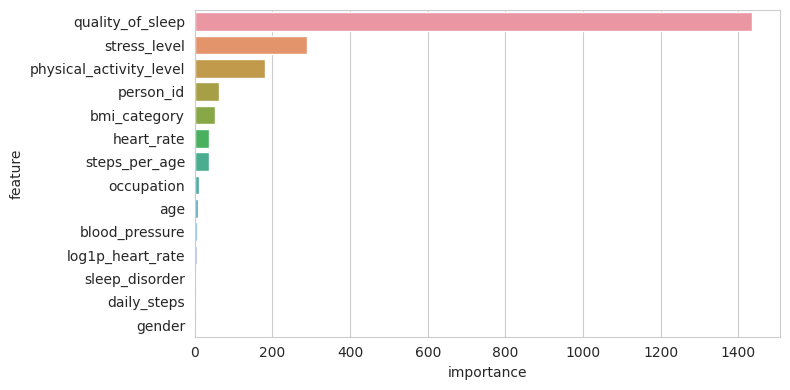

In [17]:
imp_arrays = []
for m in lgb_models:
    try:
        imp = m.feature_importance(importance_type='gain')
    except:
        imp = m.feature_importance()
    imp_arrays.append(imp)

importances = np.mean(imp_arrays, axis=0)
imp_df = pd.DataFrame({
    "feature": top_features,
    "importance": importances
}).sort_values("importance", ascending=False).reset_index(drop=True)

plt.figure(figsize=(8, max(4, 0.25 * len(imp_df))))
sns.barplot(x='importance', y='feature', data=imp_df)
plt.tight_layout()
plt.show()

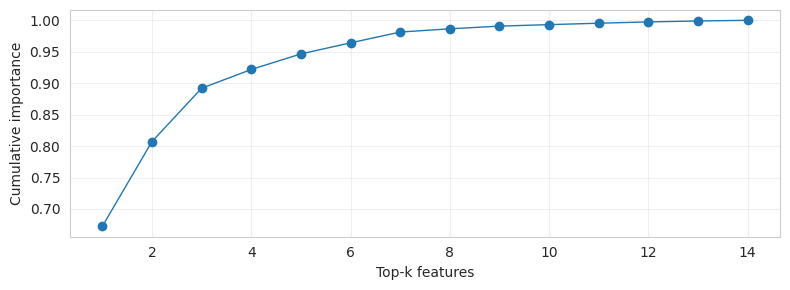

In [18]:
plt.figure(figsize=(8,3))
cum = imp_df['importance'].cumsum() / (imp_df['importance'].sum() + 1e-12)
plt.plot(np.arange(1, len(cum)+1), cum, marker='o', linewidth=1)
plt.xlabel("Top-k features")
plt.ylabel("Cumulative importance")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
full_ds = TabularDataset(X_scaled, y_arr)
full_dl = DataLoader(full_ds, batch_size=min(32, len(full_ds)), shuffle=True)

final_model = MLP(X_scaled.shape[1]).to(DEVICE)
opt = torch.optim.AdamW(final_model.parameters(), lr=1e-3, weight_decay=1e-5)
loss_fn = nn.SmoothL1Loss()

for e in range(150):
    final_model.train()
    for xb, yb in full_dl:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        opt.zero_grad()
        p = final_model(xb)
        loss = loss_fn(p, yb)
        loss.backward()
        opt.step()

In [20]:
best_iters = [getattr(m, "best_iteration", None) for m in lgb_models if getattr(m, "best_iteration", None) is not None]
avg_iter = int(np.mean(best_iters)) if len(best_iters) > 0 else 100
dtrain_full = lgb.Dataset(X_scaled, label=y_arr)
final_lgb = lgb.train(lgb_params, dtrain_full, num_boost_round=avg_iter)
torch.save(torch_models[0].state_dict(), "final_torch_fold0.pt")
torch.save(torch_models[0].state_dict(), "final_torch_model.pt")
final_lgb.save_model("final_lgb_model.txt")
joblib.dump(scaler, "scaler_sleep.pkl")
joblib.dump(top_features, "top_features_sleep.pkl")


['top_features_sleep.pkl']